# Personal Injury Accidents vs Population


In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt

from urban_mobility import fetch_data as fd
from urban_mobility import plotting as pl

fd.fetch_traffic_data()

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...


In [2]:
YEARS = list(range(2019, 2025))

## Data Cleaning


Aggregate the accidents and join them with the city info (`fd.get_city_aggregate`): it one-hot encodes the injury severity, groups by the columns given, joins on `"regional key"` and adds the total injuries. The result is cached under `output/artifacts`.


In [3]:
agg_methods = {
    "inj_light": "sum",
    "inj_serious": "sum",
    "inj_fatal": "sum",
    "IstFuss": "sum",
    "IstRad": "sum",
    "IstKrad": "sum",
    "IstGkfz": "sum",
}

df_merged = fd.get_city_aggregate(YEARS, ["Community_key"], agg_methods)

### Plotting vs Population


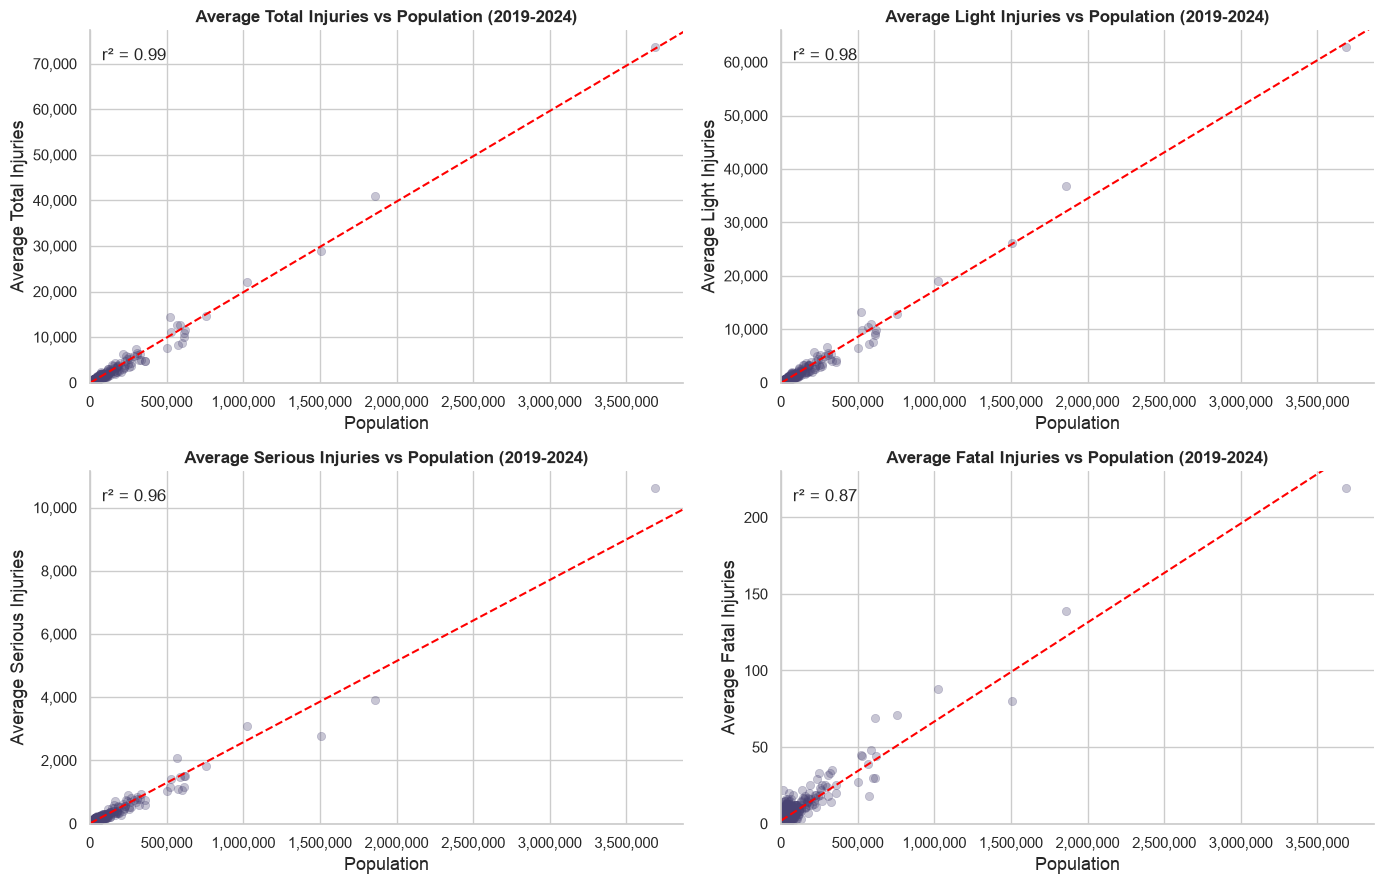

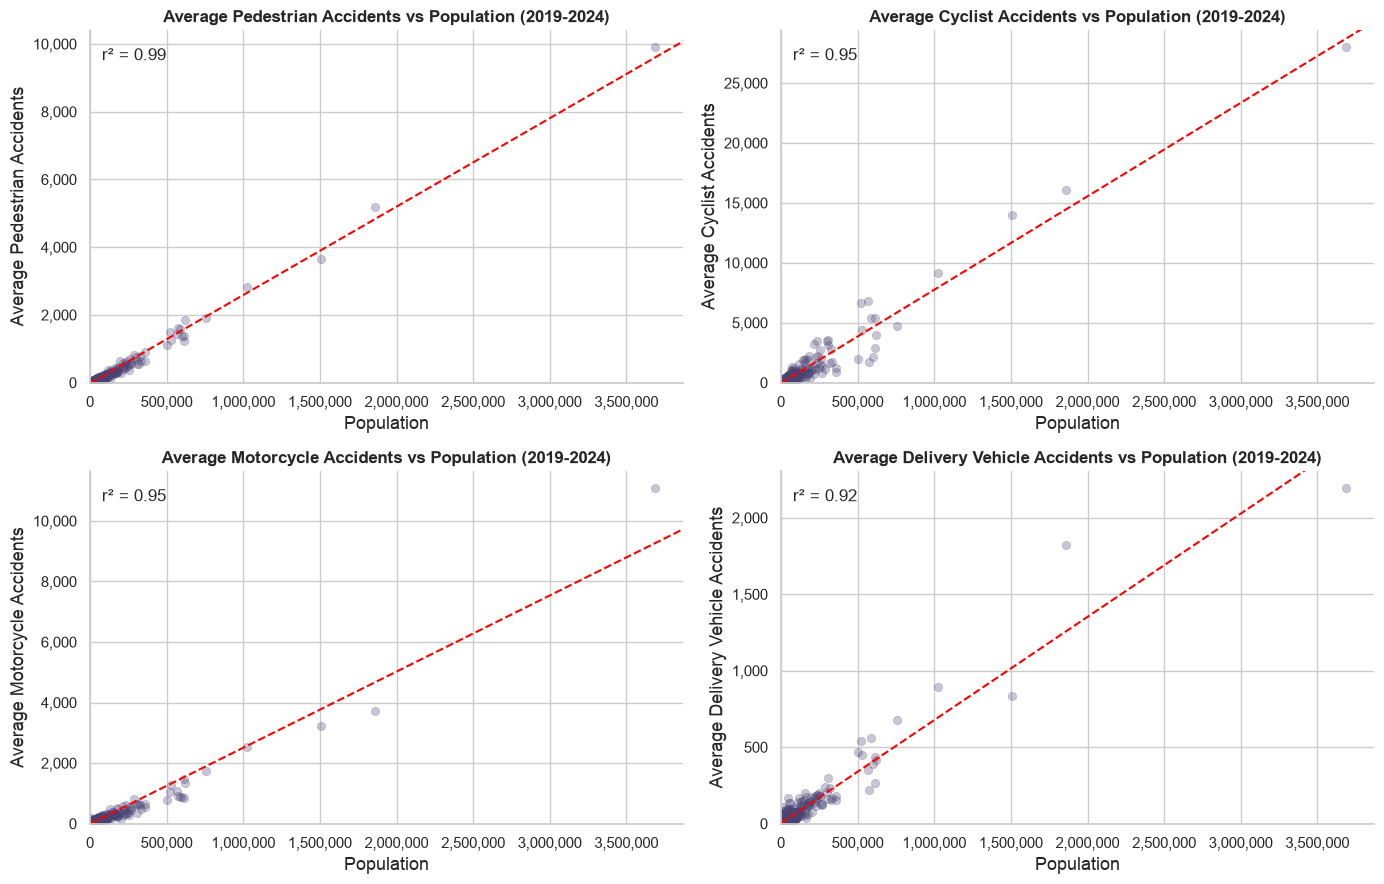

In [4]:
for group, measures in pl.MEASURE_GROUPS.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, (col, title) in zip(axes.flat, measures):
        pl.scatter_fit(
            df_merged, "population", col,
            f"Average {title} vs Population (2019-2024)",
            "Population", f"Average {title}", ax=ax,
        )
        ax.title.set_fontsize(12)
    fig.tight_layout()
    pl.save(fig, f"acc_per_pop_{group}")
    plt.show()